In [21]:
# STUDI KASUS PREDIKSI PM2.5
# Dataset Kaggle: Beijing PM2.5

!pip install -q pandas numpy matplotlib seaborn scikit-learn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from google.colab import files
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Library berhasil di-import!")

Library berhasil di-import!


In [22]:
uploaded = files.upload()

nama_file = list(uploaded.keys())[0]

df = pd.read_csv(nama_file)

print("Dataset berhasil dibaca!")
print("Ukuran dataset:", df.shape)

df.head()

Saving PRSA_data_2010.1.1-2014.12.31.csv to PRSA_data_2010.1.1-2014.12.31.csv
Dataset berhasil dibaca!
Ukuran dataset: (43824, 13)


,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


In [23]:
# Membuat kolom datetime
df["datetime"] = pd.to_datetime(
    df[["year", "month", "day", "hour"]]
)

# Menghapus data yang target PM2.5-nya kosong
df = df.dropna(subset=["pm2.5"]).copy()

# Mengisi missing value numerik dengan median
kolom_numerik = [
    "DEWP", "TEMP", "PRES", "Iws", "Is", "Ir"
]

for kolom in kolom_numerik:
    df[kolom] = df[kolom].fillna(
        df[kolom].median()
    )

# Mengisi missing value arah angin
df["cbwd"] = df["cbwd"].fillna(
    df["cbwd"].mode()[0]
)

print("Preprocessing selesai!")
print("Jumlah data:", len(df))
print("\nMissing value:")
print(df.isnull().sum())

Preprocessing selesai!
Jumlah data: 41757

Missing value:
No          0
year        0
month       0
day         0
hour        0
pm2.5       0
DEWP        0
TEMP        0
PRES        0
cbwd        0
Iws         0
Is          0
Ir          0
datetime    0
dtype: int64


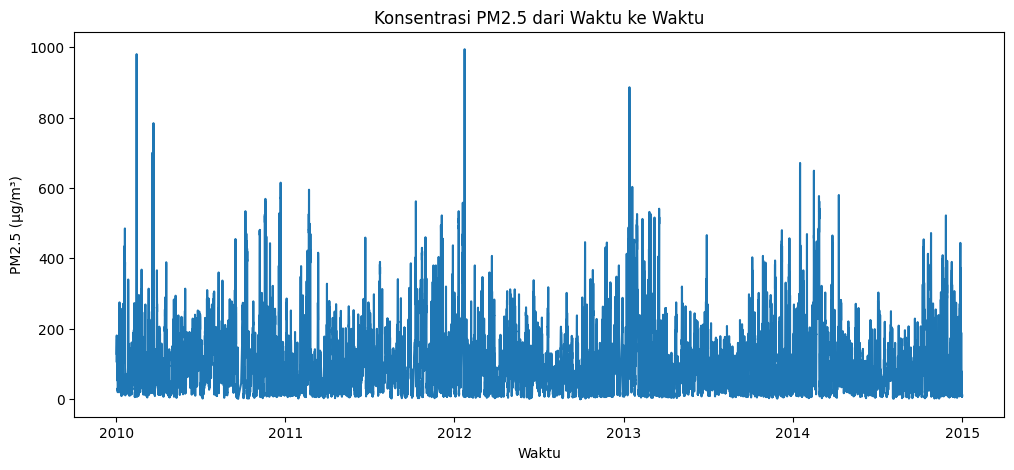

In [24]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["datetime"],
    df["pm2.5"]
)

plt.title("Konsentrasi PM2.5 dari Waktu ke Waktu")
plt.xlabel("Waktu")
plt.ylabel("PM2.5 (µg/m³)")

plt.show()

In [25]:
# One-hot encoding arah angin
df = pd.get_dummies(
    df,
    columns=["cbwd"],
    prefix="cbwd",
    dtype=int
)

# Fitur
fitur = [
    "year", "month", "day", "hour",
    "DEWP", "TEMP", "PRES",
    "Iws", "Is", "Ir"
]

fitur += [
    kolom for kolom in df.columns
    if kolom.startswith("cbwd_")
]

X = df[fitur]
y = df["pm2.5"]

print("Jumlah fitur:", len(X.columns))
print("Jumlah data:", len(X))

Jumlah fitur: 14
Jumlah data: 41757


In [26]:
# Data berdasarkan urutan waktu
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

# Membuat model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Training
model.fit(X_train, y_train)

print("Training selesai!")
print("Data training:", len(X_train))
print("Data testing:", len(X_test))

Training selesai!
Data training: 33405
Data testing: 8352


In [27]:
# Prediksi
y_pred = model.predict(X_test)

# Evaluasi
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("===== HASIL EVALUASI =====")
print("MAE  :", round(mae, 3))
print("RMSE :", round(rmse, 3))
print("R²   :", round(r2, 3))

===== HASIL EVALUASI =====
MAE  : 47.737
RMSE : 68.767
R²   : 0.468


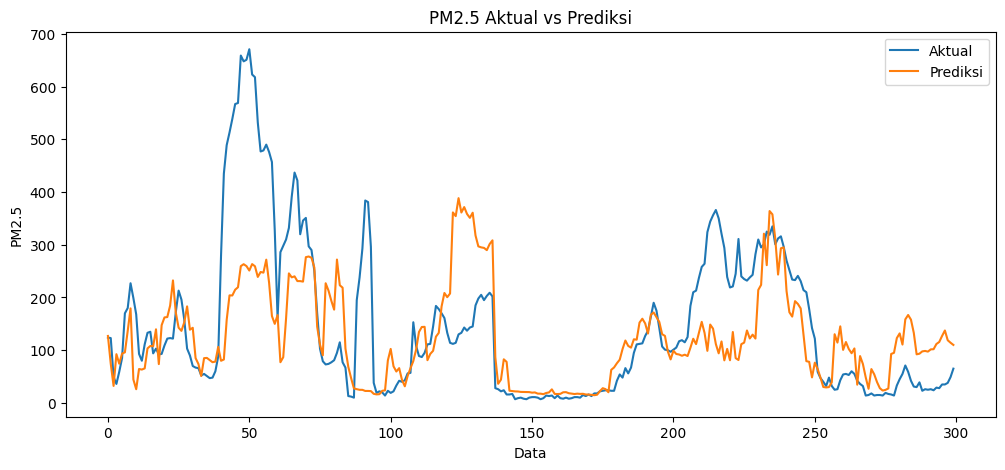

In [28]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test.values[:300],
    label="Aktual"
)

plt.plot(
    y_pred[:300],
    label="Prediksi"
)

plt.title("PM2.5 Aktual vs Prediksi")
plt.xlabel("Data")
plt.ylabel("PM2.5")

plt.legend()
plt.show()

    Feature  Importance
4      DEWP    0.248007
2       day    0.158683
5      TEMP    0.124309
1     month    0.122805
6      PRES    0.097605
7       Iws    0.089878
0      year    0.059613
3      hour    0.051541
11  cbwd_NW    0.029448
12  cbwd_SE    0.006829


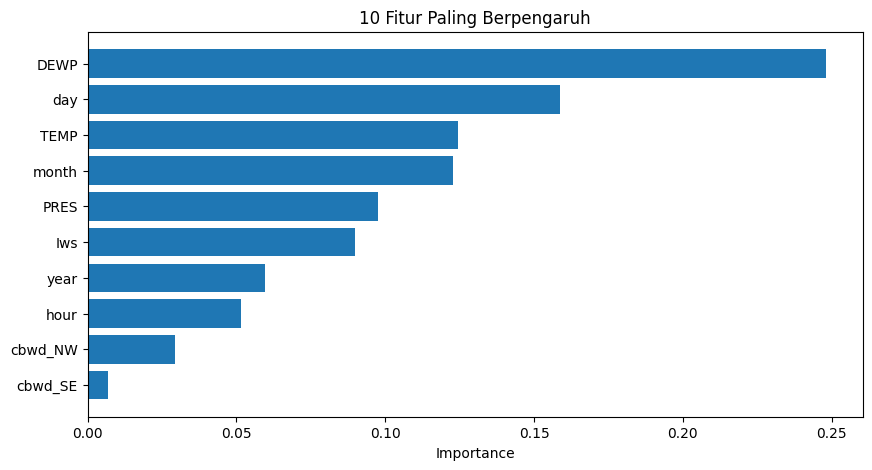

In [29]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance.head(10))

plt.figure(figsize=(10, 5))

plt.barh(
    importance.head(10)["Feature"],
    importance.head(10)["Importance"]
)

plt.title("10 Fitur Paling Berpengaruh")
plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

In [30]:
# Simpan model
joblib.dump(
    model,
    "model_pm25_random_forest.pkl"
)

# Simpan hasil prediksi
hasil = pd.DataFrame({
    "Aktual": y_test.values,
    "Prediksi": y_pred
})

hasil.to_csv(
    "hasil_prediksi_pm25.csv",
    index=False
)

print("Model dan hasil prediksi berhasil disimpan.")

print("\n===== KESIMPULAN =====")
print("Model Random Forest berhasil digunakan")
print("untuk memprediksi konsentrasi PM2.5.")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

print("\nPengembangan selanjutnya:")
print("- Data sensor IoT")
print("- Dashboard monitoring")
print("- GPU / HPC")
print("- Prediksi secara real-time")

Model dan hasil prediksi berhasil disimpan.

===== KESIMPULAN =====
Model Random Forest berhasil digunakan
untuk memprediksi konsentrasi PM2.5.
MAE  : 47.737
RMSE : 68.767
R²   : 0.468

Pengembangan selanjutnya:
- Data sensor IoT
- Dashboard monitoring
- GPU / HPC
- Prediksi secara real-time


In [31]:
from google.colab import files

files.download("model_pm25_random_forest.pkl")
files.download("hasil_prediksi_pm25.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>